# Génération de Motifs Quantiques — FRQI

Imaginez et concevez des circuits FRQI qui génèrent des motifs visuels — saurez-vous par exemple créer un circuit de seulement quelques portes capable de produire un damier ?

Le but de ce défi est de créer de beaux motifs quantiques sous forme d'image, en utilisant l'encodage **FRQI** ($\lceil \log_2(N) \rceil + 1$ qubits au lieu de $N$).

> **Règle importante :**
- Pour les motifs réguliers simples (**bruit, damier, bandes**), on attend des **circuits malins** qui exploitent directement les bits d'adresse.
- Pour les motifs plus complexes (**rectangles, niveaux de gris, fractales**), un encodage **adresse par adresse** (`MCX` / `MCRY`) est attendu.

### Partie 1 : Reproduction de Motifs
Nous vous proposons des motifs cibles. Votre objectif est de trouver le circuit FRQI capable de les produire :
1. **Bruit aléatoire** - Neige télévisuelle.
2. **Damier Quantique** - Motif alterné.
3. **Lignes horizontales et verticales** (déterministes).
4. **Rectangles Concentriques** - Carrés imbriqués.
5. **Rectangles en niveaux de gris** - Du centre vers l'extérieur.
6. **Fractales Quantiques** *(bonus)* - Motifs auto-similaires.


In [52]:
import importlib
import math
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit import QuantumCircuit, transpile

import utils_quantum
importlib.reload(utils_quantum)
from utils_quantum import run_simulation
from utils_images import display_image

In [53]:
# 1. Connexion IBM Cloud (PINQ2)
service = QiskitRuntimeService(
    channel="ibm_cloud",
    token="XTniEHDa4bWL-isMEF69tkfj0RyEcO7NNXv4kZjNHyx0", 
    instance="crn:v1:bluemix:public:quantum-computing:us-east:a/d2c50f33c43a44abb94280706332351d:fa6ae649-f03a-4eb4-9434-1c3f512203fe::"
)

qiskit_runtime_service._discover_account:WARNING:2026-06-01 23:31:52,726: Loading account with the given token. A saved account will not be used.


## Motif 1 - Bruit aléatoire
Vous devez produire une image entièrement aléatoire, comme une neige télévisuelle. Chaque pixel est tiré indépendamment des autres, avec 50 % de chance d’être noir et 50 % de chance d’être blanc.

![random_pattern.png](images/random_noise.png)

Visualisez ensuite quatre reconstructions indépendantes côte à côte, comme dans l’illustration

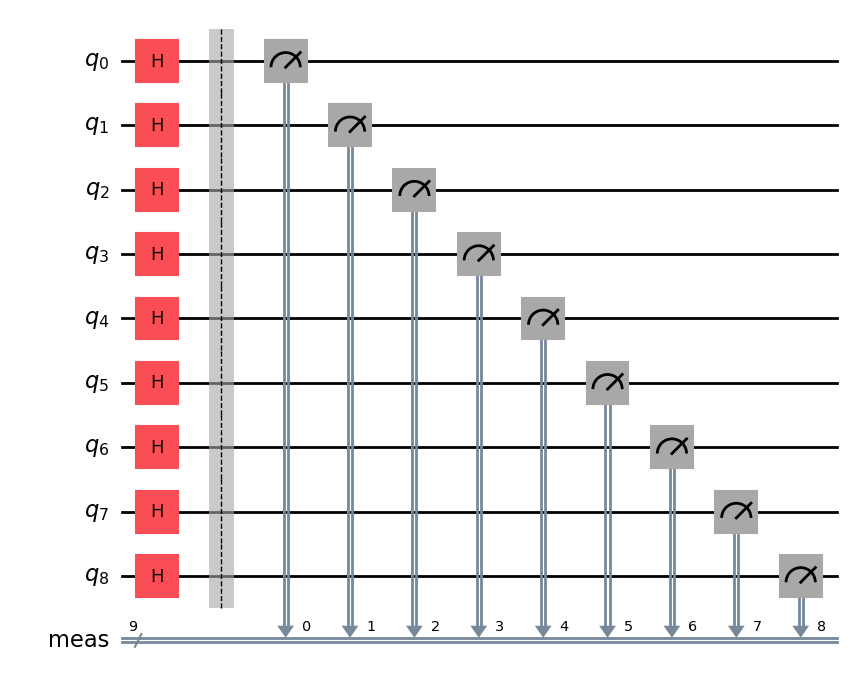

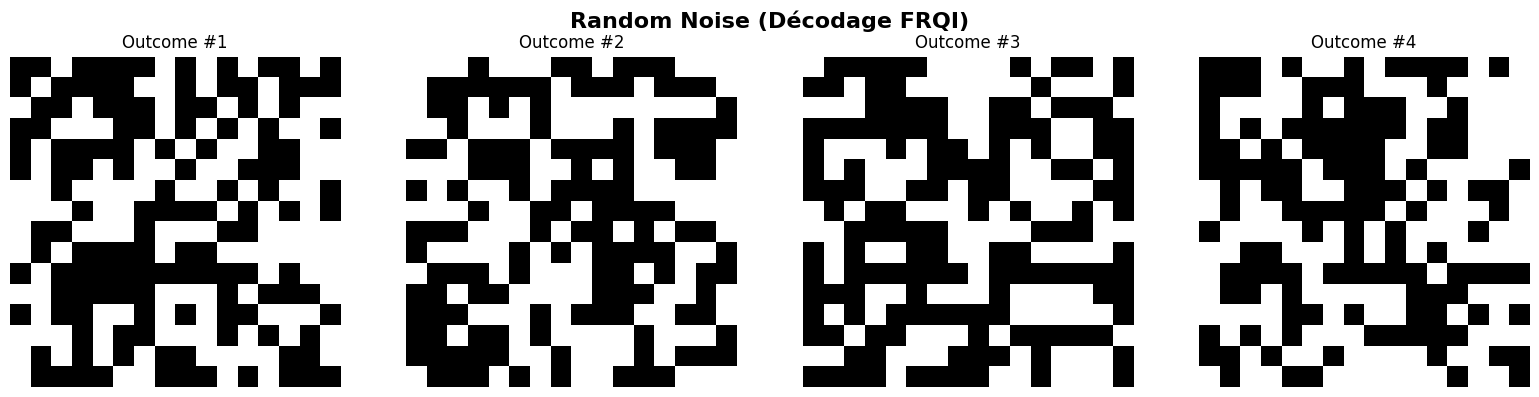

In [63]:
# 1. Création du circuit FRQI (Bruit aléatoire)
n_qubits = 9 # 8 qubits d'adresse + 1 qubit de couleur
qc_bruit = QuantumCircuit(n_qubits)

# Superposition totale et mesure
qc_bruit.h(range(n_qubits))
qc_bruit.measure_all()
display(qc_bruit.draw('mpl'))

# 2. Simulation et décodage des images
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Random Noise (Décodage FRQI)", fontsize=16, fontweight='bold')

for i in range(4):
    result = run_simulation(qc_bruit) 
    image = np.zeros(256) 
    
    # Décodage des états quantiques vers les pixels
    for state, _ in result.items():
        state_clean = state.replace(" ", "")
        color, address = int(state_clean[0]), int(state_clean[1:], 2)
        image[address] = color
        
    # Affichage sur le graphique correspondant
    axes[i].imshow(image.reshape((16, 16)), cmap='gray', vmin=0, vmax=1)
    axes[i].set_title(f"Outcome #{i+1}")
    axes[i].axis('off') 

plt.tight_layout()
plt.show()

## Motif 2 - Damier Quantique (Quantum Checkerboard) - Motif alterné.

Créer un motif de damier classique (alternance de pixels noirs et blancs). Le circuit est **déterministe** : il produit toujours le même damier.

**2 :** Pouvez-vous aussi trouver comment obtenir le négatif à partir de ce premier circuit ?

![chess](images/chess.png)

Note : le damier et son négatif sont reconstruits séparément, à partir de circuits distincts.

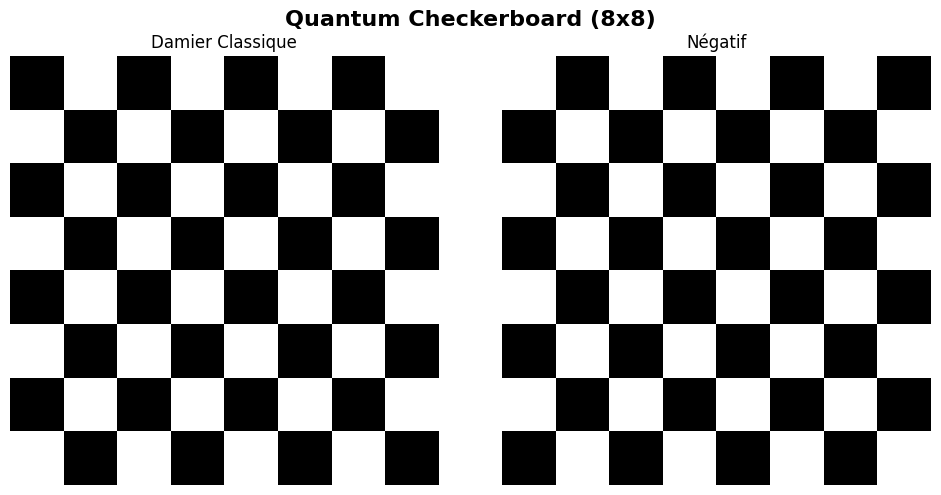

In [55]:
# 1. Création des circuits FRQI (8x8 : 6 qubits d'adresse, 1 de couleur)
qc_damier = QuantumCircuit(7)
qc_damier.h(range(6))
qc_damier.cx(0, 6)
qc_damier.cx(3, 6)
qc_damier.measure_all()

qc_negatif = QuantumCircuit(7)
qc_negatif.h(range(6))
qc_negatif.x(6) # Inversion de la couleur
qc_negatif.cx(0, 6)
qc_negatif.cx(3, 6)
qc_negatif.measure_all()

# Affichage groupé des deux circuits
#display(qc_damier.draw('mpl'), qc_negatif.draw('mpl'))

# 2. Exécution et décodage
def decode_8x8(result_counts):
    image = np.zeros(64) 
    for state, _ in result_counts.items():
        state_clean = state.replace(" ", "")
        color, address = int(state_clean[0]), int(state_clean[1:], 2)
        if address < 64: 
            image[address] = color
    return image.reshape((8, 8))

# On exécute et on décode 
img_damier = decode_8x8(run_simulation(qc_damier))
img_negatif = decode_8x8(run_simulation(qc_negatif))

# 3. Visualisation
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle("Quantum Checkerboard (8x8)", fontsize=16, fontweight='bold')

#affichage
configs = [(img_damier, "Damier Classique"), (img_negatif, "Négatif")]

for ax, (img, title) in zip(axes, configs):
    ax.imshow(img, cmap='gray', vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

## Motif 3 - Lignes horizontales (déterministe)
Le motif est toujours le même à chaque exécution : lignes alternées noir/blanc. Pas d'aléatoire !

![Lignes horizontales](images/frqi_bar_horiz.png)

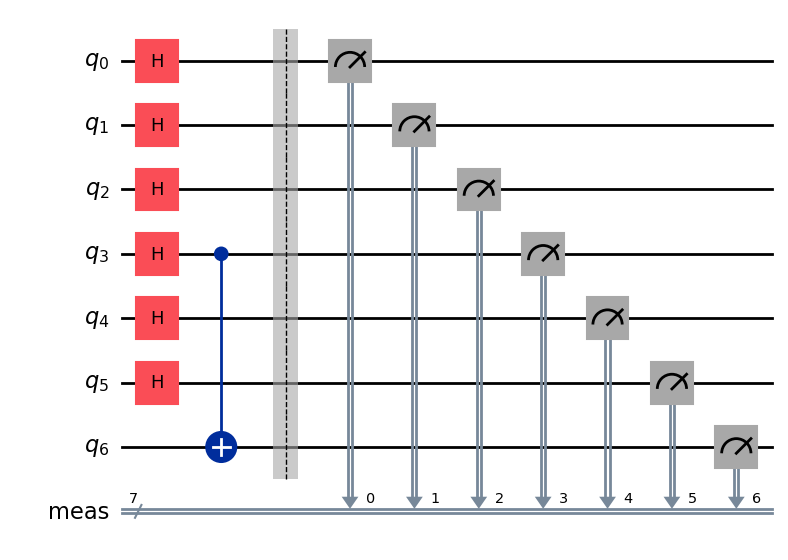

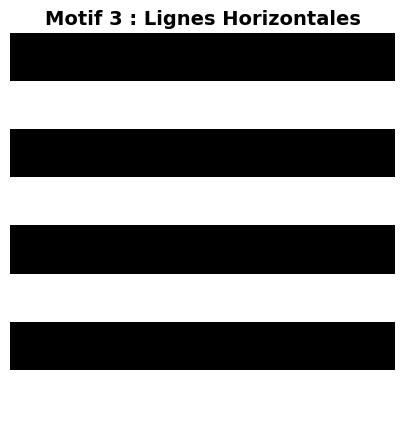

In [56]:
# 1. Circuit FRQI : Lignes horizontales (8x8)
qc_lignes = QuantumCircuit(7)
qc_lignes.h(range(6))
qc_lignes.cx(3, 6) # La couleur q6 qui copie la parité de la ligne q3
qc_lignes.measure_all()

display(qc_lignes.draw('mpl'))

# 2. Exécution et décodage 
img_lignes = decode_8x8(run_simulation(qc_lignes))

# 3. Visualisation
plt.figure(figsize=(5, 5))
plt.imshow(img_lignes, cmap='gray', vmin=0, vmax=1)
plt.title("Motif 3 : Lignes Horizontales", fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()

## Motif 4 - Lignes verticales (déterministe)
Même principe, mais vertical. Le motif est toujours identique.

![Lignes verticales](images/frqi_bar_ver.png)

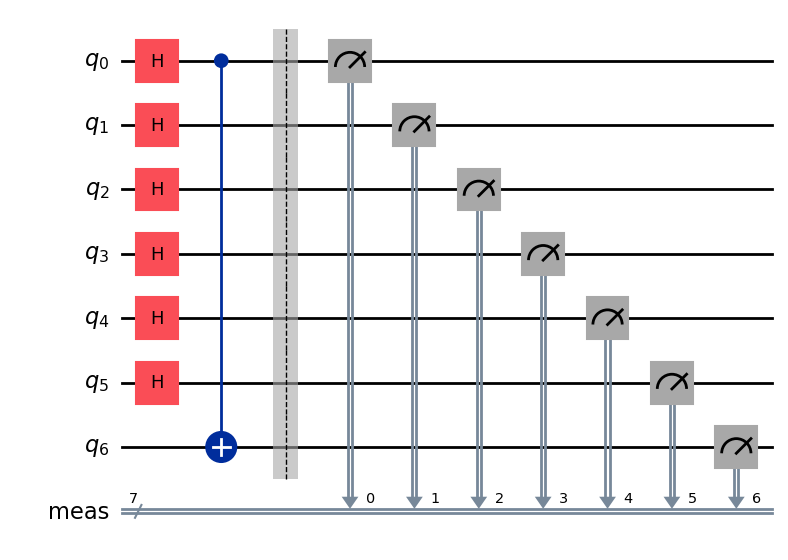

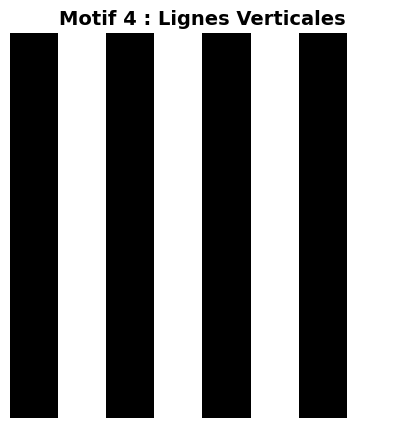

In [57]:
# 1. Circuit FRQI : Lignes verticales (8x8)
qc_verticales = QuantumCircuit(7)
qc_verticales.h(range(6))
qc_verticales.cx(0, 6) # La couleur copie q0 qui génère des lignes verticales
qc_verticales.measure_all()

display(qc_verticales.draw('mpl'))

# 2. Exécution et décodage 
# (On réutilise toujours decode_8x8 défini plus haut !)
img_verticales = decode_8x8(run_simulation(qc_verticales))

# 3. Visualisation
plt.figure(figsize=(5, 5))
plt.imshow(img_verticales, cmap='gray', vmin=0, vmax=1)
plt.title("Motif 4 : Lignes Verticales", fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()

## Motif 5 - Rectangles Concentriques — Carrés imbriqués

> **Important :** ce motif est différent du damier et des bandes.
Ici, on attend une approche adresse par adresse.
Autrement dit, il faut traiter chaque pixel individuellement.

Ici, on veut construire des rectangles concentriques, c’est-à-dire des carrés imbriqués qui alternent noir et blanc de l’extérieur vers l’intérieur.

Pour décrire ce motif, on note une image de taille $R \times C$ :
- $R$ = nombre de lignes
- $C$ = nombre de colonnes

Pour un pixel situé à la ligne $r$ et à la colonne $c$, on définit sa **couche** $L(r,c)$ comme sa distance au bord le plus proche :

$$
L(r,c) = \min(r, c, R-1-r, C-1-c)
$$

Ainsi :
- la couche $0$ correspond au bord extérieur,
- la couche $1$ au premier rectangle intérieur,
- la couche $2$ au suivant,
- et ainsi de suite jusqu’au centre.

**Votre objectif :** trouver un circuit FRQI qui reproduit ce motif en respectant cette alternance noir/blanc.


![Rectangles concentriques](images/frqi_carre.png)


Portes MCX nécessaires : 40
Profondeur du circuit : 121


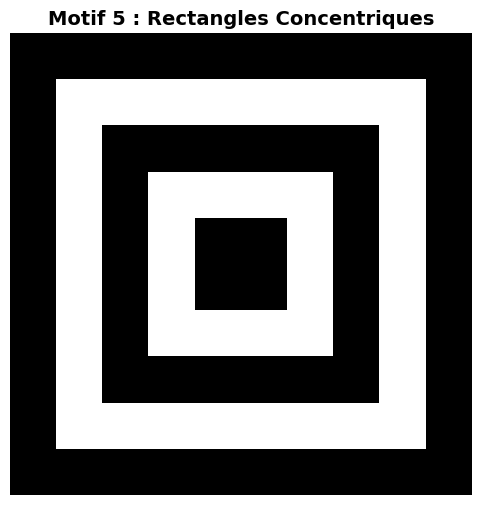

In [58]:
# 1. Calcul des pixels blancs pour les carrés concentriques (10x10)
white_addrs = [
    r * 10 + c for r in range(10) for c in range(10)
    if min(r, c, 9 - r, 9 - c) in (1, 3) # Couches 1 et 3
]
print(f"Portes MCX nécessaires : {len(white_addrs)}")

# 2. Circuit FRQI : Encodage pixel par pixel (7 qubits adresse + 1 couleur)
qc_carres = QuantumCircuit(8) 
qc_carres.h(range(7))

for addr in white_addrs:
    bin_str = format(addr, '07b')
    # On repère les indices des bits à '0' pour préparer le MCX
    zero_indices = [i for i, bit in enumerate(reversed(bin_str)) if bit == '0']
    
    # Application des portes en groupe (plus lisible et efficace)
    if zero_indices: qc_carres.x(zero_indices)
    qc_carres.mcx(list(range(7)), 7)
    if zero_indices: qc_carres.x(zero_indices) # Uncomputation

qc_carres.measure_all()
print(f"Profondeur du circuit : {qc_carres.depth()}")

# 3. Exécution et décodage (65536 shots pour bien couvrir les 128 adresses possibles)
def decode_10x10(result_counts):
    image = np.zeros(100)
    for state, _ in result_counts.items():
        state_clean = state.replace(" ", "")
        color, address = int(state_clean[0]), int(state_clean[1:], 2)
        if address < 100: 
            image[address] = color
    return image.reshape((10, 10))

img_carres = decode_10x10(run_simulation(qc_carres, shots=65536))

# 4. Visualisation
plt.figure(figsize=(6, 6))
plt.imshow(img_carres, cmap='gray', vmin=0, vmax=1)
plt.title("Motif 5 : Rectangles Concentriques", fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()

## Motif 6 - Rectangles en niveaux de gris — Du centre vers l'extérieur

Même idée que les rectangles concentriques, mais **chaque couche a une intensité différente**.

Rappel utile :

$$
\phi = 2\arcsin\left(\sqrt{I/255}\right)
$$

![Rectangles niveaux de gris](images/frqi_carre_gris.png)

Circuit généré ! Profondeur initiale : 175
Transpilation terminée ! Profondeur réelle : 3852


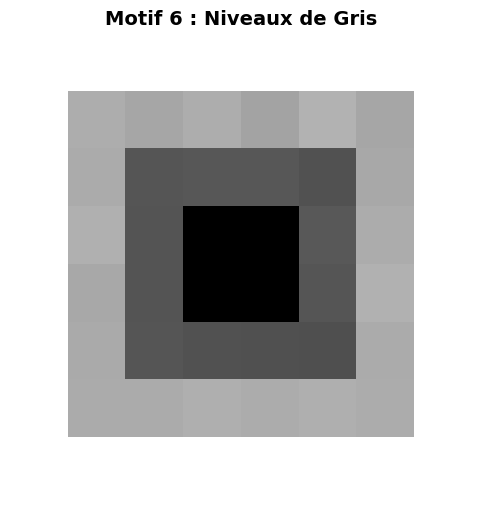

In [64]:
# 1. Création du Circuit FRQI "Niveaux de Gris" (8x8)
qc_gris = QuantumCircuit(7)
qc_gris.h(range(6))

# Couche maximale au centre (couche 3 pour du 8x8)
max_layer = 3 

for r in range(8):
    for c in range(8):
        layer = min(r, c, 7 - r, 7 - c)
        intensity_ratio = 1.0 - (layer / max_layer) # 1.0 au bord, 0.0 au centre
        
        if intensity_ratio > 0:
            phi = 2 * math.asin(math.sqrt(intensity_ratio))
            address = r * 8 + c
            bin_str = format(address, '06b')
            
            # Préparation de l'adresse
            zero_indices = [i for i, bit in enumerate(reversed(bin_str)) if bit == '0']
            
            if zero_indices: qc_gris.x(zero_indices)
            
            # Porte Ry multi-contrôlée pour encoder l'angle
            mc_ry = RYGate(phi).control(6)
            qc_gris.append(mc_ry, list(range(7)))
            
            if zero_indices: qc_gris.x(zero_indices) # Uncomputation

qc_gris.measure_all()
print(f"Circuit généré ! Profondeur initiale : {qc_gris.depth()}")

# 2. Transpilation, Exécution et Décodage
qc_gris_transpiled = transpile(qc_gris, backend=simulator)
print(f"Transpilation terminée ! Profondeur réelle : {qc_gris_transpiled.depth()}")

def decode_grayscale_8x8(result_counts):
    counts_1 = np.zeros(64)
    counts_total = np.zeros(64)
    
    for state, count in result_counts.items():
        state_clean = state.replace(" ", "")
        color, address = int(state_clean[0]), int(state_clean[1:], 2)
        
        if address < 64:
            counts_total[address] += count
            if color == 1:
                counts_1[address] += count
                
    # Division vectorielle sécurisée (évite l'erreur de division par zéro)
    image = np.divide(counts_1, counts_total, out=np.zeros(64), where=counts_total != 0)
    return image.reshape((8, 8))

# Exécution (100 000 shots pour lisser les probabilités des niveaux de gris)
result_gris = run_simulation(qc_gris_transpiled, shots=100000)
img_gris = decode_grayscale_8x8(result_gris)

# 3. Visualisation
plt.figure(figsize=(6, 6))
plt.imshow(img_gris, cmap='gray', vmin=0, vmax=1)
plt.title("Motif 6 : Niveaux de Gris", fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()

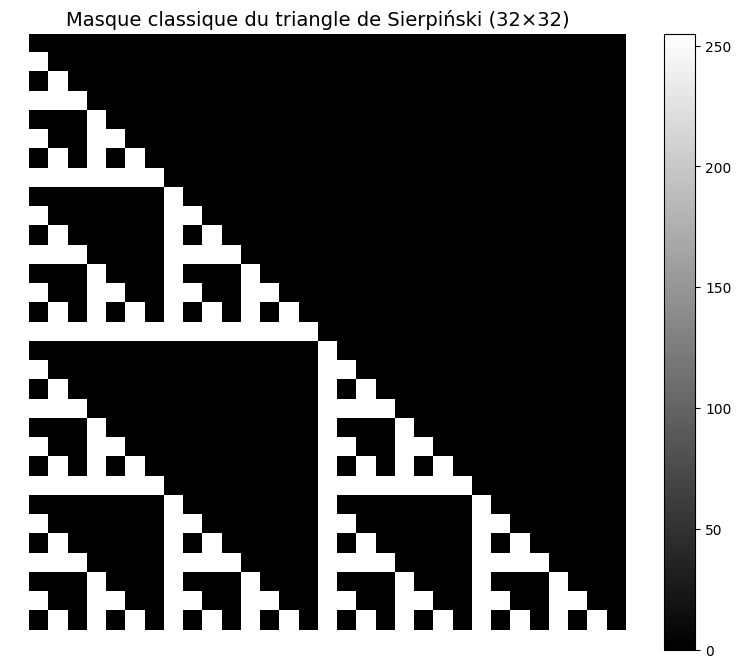

In [60]:
def sierpinski_triangle_mask(size=32):
    """Return a binary mask (size x size) for the Sierpiński triangle."""
    mask = np.zeros((size, size), dtype=int)
    for row in range(size):
        for col in range(size):
            if col <= row and (row & col) == col:
                mask[row, col] = 1
    return mask


size = 32
mask = sierpinski_triangle_mask(size)
display_image(mask * 255, f"Masque classique du triangle de Sierpiński ({size}×{size})", cmap='gray')

**Objectif : Avec un seul circuit, reconstruire :**
- Image normale
- Image inversée
  
![Triangle de Sierpiński](images/fractal.png)

Pixels blancs à encoder (portes MCX) : 243
Circuit brut généré ! Profondeur : 726
Transpilation terminée ! Profondeur réelle : 27885


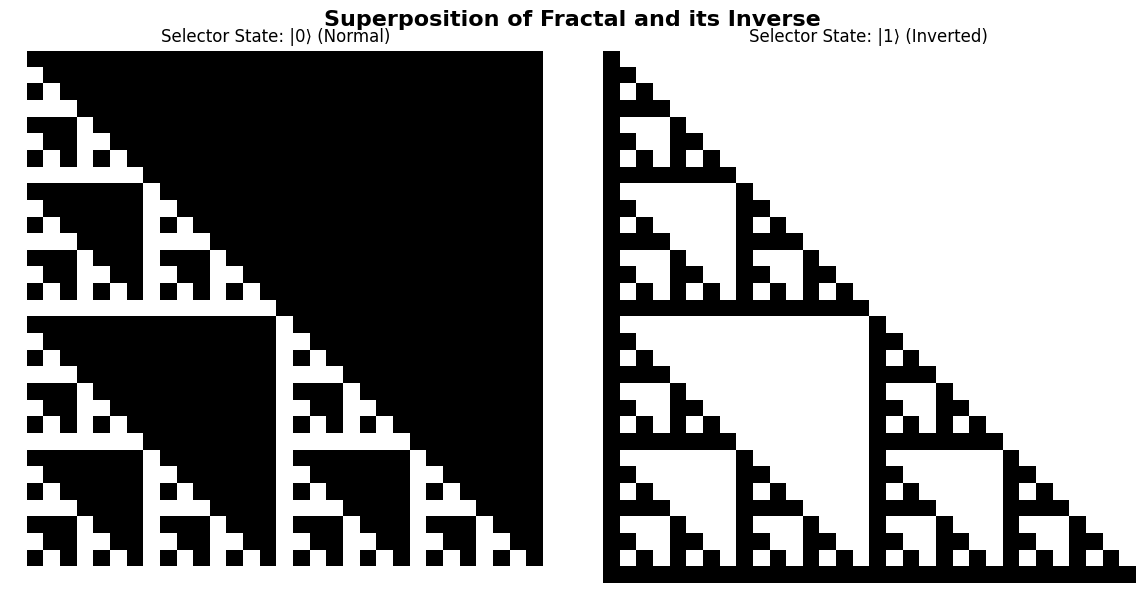

In [67]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile

# 1. Génération des adresses des pixels blancs pour la fractale (32x32)
white_addrs = [
    r * 32 + c for r in range(32) for c in range(32) 
    if ((31 - r) & c) == 0
]
print(f"Pixels blancs à encoder (portes MCX) : {len(white_addrs)}")

# 2. Circuit FRQI : Double Fractale (10 qubits adresse, 1 couleur, 1 sélecteur)
qc_fractal = QuantumCircuit(12)
qc_fractal.h(range(10)) # Superposition adresses
qc_fractal.h(11)        # Superposition sélecteur

for addr in white_addrs:
    bin_str = format(addr, '010b')
    zero_indices = [i for i, bit in enumerate(reversed(bin_str)) if bit == '0']
    
    if zero_indices: qc_fractal.x(zero_indices)
    qc_fractal.mcx(list(range(10)), 10)
    if zero_indices: qc_fractal.x(zero_indices) # Uncomputation

# Une seule porte CNOT pour générer l'image inversée selon le sélecteur !
qc_fractal.cx(11, 10)
qc_fractal.measure_all()
print(f"Circuit brut généré ! Profondeur : {qc_fractal.depth()}")

#transpilation
qc_transpiled = transpile(qc_fractal, basis_gates=['cx', 'id', 'rz', 'sx', 'x'])

print(f"Transpilation terminée ! Profondeur réelle : {qc_transpiled.depth()}")

# 3. Exécution et Décodage (300 000 shots pour couvrir les 2048 états)
def decode_fractal_split(result_counts):
    img_norm, img_inv = np.zeros(1024), np.zeros(1024)
    
    for state, _ in result_counts.items():
        state_clean = state.replace(" ", "")
        selector, color, address = int(state_clean[0]), int(state_clean[1]), int(state_clean[2:], 2)
        
        if address < 1024:
            if selector == 0:
                img_norm[address] = color
            else:
                img_inv[address] = color
                
    return img_norm.reshape((32, 32)), img_inv.reshape((32, 32))

result_fractal = run_simulation(qc_transpiled, shots=300000)
img_norm, img_inv = decode_fractal_split(result_fractal)

# 4. Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle("Superposition of Fractal and its Inverse", fontsize=16, fontweight='bold')

configs = [(img_norm, "Selector State: |0⟩ (Normal)"), (img_inv, "Selector State: |1⟩ (Inverted)")]

for ax, (img, title) in zip(axes, configs):
    ax.imshow(img, cmap='gray', vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()